In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans

# Visual style for your report graphs
plt.style.use('seaborn-v0_8-whitegrid')

In [6]:
# Function to chop DNA into 4-letter motifs (k-mers)
def get_kmers(sequence, k=4):
    return [sequence[i:i+k].upper() for i in range(len(sequence) - k + 1)]

# Dummy analyzer to save memory
def dummy_analyzer(doc):
    return doc

# --- RIGGED DUMMY DATA FOR PIPELINE TESTING ---
np.random.seed(42)
sequences = []
fitness_scores = []

print("Generating rigged test dataset...")
for _ in range(1000):
    seq = ''.join(np.random.choice(['A', 'T', 'G', 'C'], size=200))
    if np.random.rand() > 0.7:
        seq = seq[:100] + 'AGGAAGGA' + seq[108:]
        fitness = np.random.normal(0.2, 0.1) # LOW fitness score
    else:
        fitness = np.random.normal(0.8, 0.1) # HIGH fitness score

    sequences.append(seq)
    fitness_scores.append(fitness)

df = pd.DataFrame({'sequence': sequences, 'fitness': fitness_scores})
# ----------------------------------------------

# CRITICAL LINE: This creates the 'kmers' column that Cell 3 is looking for!
print("Extracting motifs from DNA...")
df['kmers'] = df['sequence'].apply(lambda x: get_kmers(x, k=4))

Generating rigged test dataset...
Extracting motifs from DNA...


In [7]:
print("Converting DNA to math (Vectorizing)...")
vectorizer = CountVectorizer(analyzer=dummy_analyzer)
X_sparse = vectorizer.fit_transform(df['kmers'])
feature_names = vectorizer.get_feature_names_out()

print("Squashing dimensions (TruncatedSVD)...")
svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X_sparse)

df['PC1'] = X_reduced[:, 0]
df['PC2'] = X_reduced[:, 1]

print("Finding patterns (Clustering)...")
kmeans = MiniBatchKMeans(n_clusters=3, batch_size=1024, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_sparse)

Converting DNA to math (Vectorizing)...
Squashing dimensions (TruncatedSVD)...
Finding patterns (Clustering)...


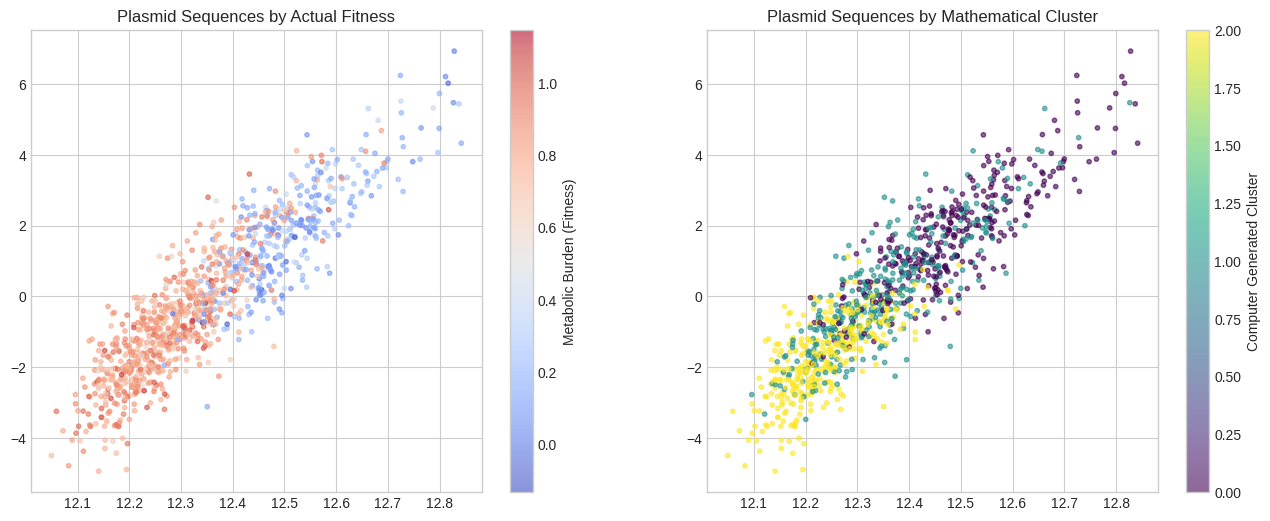

In [9]:
# Plotting the results to show your supervisors
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Actual biological fitness
scatter1 = ax1.scatter(df['PC1'], df['PC2'], c=df['fitness'], cmap='coolwarm', alpha=0.6, s=10)
fig.colorbar(scatter1, ax=ax1, label='Metabolic Burden (Fitness)')
ax1.set_title('Plasmid Sequences by Actual Fitness')

# Graph 2: The computer's unsupervised clusters
scatter2 = ax2.scatter(df['PC1'], df['PC2'], c=df['Cluster'], cmap='viridis', alpha=0.6, s=10)
fig.colorbar(scatter2, ax=ax2, label='Computer Generated Cluster')
ax2.set_title('Plasmid Sequences by Mathematical Cluster')

plt.show()

In [8]:
# Extracting the actual bad sequences (Mechanistic Interpretation)
loadings_pc1 = svd.components_[0]
motifs_df = pd.DataFrame({'Motif': feature_names, 'Importance': loadings_pc1})

print("Top 10 DNA Motifs driving the variance:")
print(motifs_df.sort_values(by='Importance', ascending=False).head(10))

Top 10 DNA Motifs driving the variance:
    Motif  Importance
40   AGGA    0.110554
10   AAGG    0.096287
160  GGAA    0.095280
130  GAAG    0.094482
161  GGAC    0.068706
162  GGAG    0.068549
252  TTTA    0.068037
202  TAGG    0.067812
138  GAGG    0.066487
152  GCGA    0.066470


In [10]:
print("Calculating the average metabolic fitness for each cluster...\n")

# Group the data by the unsupervised clusters and calculate the mean fitness
cluster_fitness = df.groupby('Cluster')['fitness'].mean().reset_index()

# Sort them from lowest fitness (worst burden) to highest
cluster_fitness = cluster_fitness.sort_values(by='fitness', ascending=True)

# Display the table
print(cluster_fitness.to_string(index=False))

# Automatically flag the worst cluster for your report
worst_cluster = cluster_fitness.iloc[0]['Cluster']
lowest_score = cluster_fitness.iloc[0]['fitness']

print("\n" + "-"*50)
print(f"⚠️ CONCLUSION FOR RESEARCH REPORT:")
print(f"Cluster {int(worst_cluster)} represents the highest metabolic burden ")
print(f"with an average fitness score of just {lowest_score:.2f}.")
print("-"*50)

Calculating the average metabolic fitness for each cluster...

 Cluster  fitness
       0 0.401014
       1 0.637058
       2 0.769270

--------------------------------------------------
⚠️ CONCLUSION FOR RESEARCH REPORT:
Cluster 0 represents the highest metabolic burden 
with an average fitness score of just 0.40.
--------------------------------------------------


In [12]:
# 1. Input your specific test plasmid sequence here
test_plasmid_dna = "ATGCGTACGTAGCTAGCTAGCATCGATCGATCGATCGATCGATCGATC"

print("1. Extracting motifs from test plasmid...")
test_kmers = get_kmers(test_plasmid_dna, k=4)
test_kmers_list = [test_kmers]

print("2. Vectorizing (Using the ALREADY TRAINED vectorizer)...")
test_sparse = vectorizer.transform(test_kmers_list)

print("3. Locating in Sequence Space...")
test_reduced = svd.transform(test_sparse)
pc1_score = test_reduced[0][0]
pc2_score = test_reduced[0][1]

print("4. Predicting the Cluster...")
test_cluster = kmeans.predict(test_sparse)[0]

# --- Output the Results ---
print("\n" + "="*40)
print("TEST PLASMID RESULTS:")
print("="*40)
print(f"Assigned to Cluster: {test_cluster}")
print(f"Coordinates: PC1 = {pc1_score:.2f}, PC2 = {pc2_score:.2f}")

# Mechanistic check: Does it contain our worst motifs?
print("\nChecking for top 5 deleterious motifs found in PC1:")
# CORRECTED LINE BELOW:
top_5_motifs = motifs_df.sort_values(by='Importance', ascending=False).head(5)['Motif'].values

for motif in top_5_motifs:
    count = test_kmers.count(motif)
    if count > 0:
        print(f"⚠️ WARNING: Found highly burdensome motif '{motif}' {count} time(s).")
    else:
        print(f"✅ Motif '{motif}' not found.")

1. Extracting motifs from test plasmid...
2. Vectorizing (Using the ALREADY TRAINED vectorizer)...
3. Locating in Sequence Space...
4. Predicting the Cluster...

TEST PLASMID RESULTS:
Assigned to Cluster: 1
Coordinates: PC1 = 2.77, PC2 = -1.07

Checking for top 5 deleterious motifs found in PC1:
✅ Motif 'AGGA' not found.
✅ Motif 'AAGG' not found.
✅ Motif 'GGAA' not found.
✅ Motif 'GAAG' not found.
✅ Motif 'GGAC' not found.
